In [8]:
# !pip install skrebate

In [9]:
# =========================
# 1. 라이브러리
# =========================
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from skrebate import MultiSURF

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, recall_score

# =========================
# 2. 데이터 불러오기
# =========================
data = pd.read_csv(r"../../data/processed/data_vif.csv")

target_col = "Risk_Label"
date_col = "Date"

if target_col not in data.columns:
    raise ValueError(f"{target_col} 컬럼이 없습니다.")

if date_col not in data.columns:
    raise ValueError(f"{date_col} 컬럼이 없습니다.")

# =========================
# Signal 기준범주 Stay 복원
# MultiSURF 거리계산용
# =========================

signal_prefixes = ["Signal1", "Signal2", "Signal3", "Signal4"]

for sig in signal_prefixes:
    buy_col = f"{sig}_Buy"
    sell_col = f"{sig}_Sell"
    stay_col = f"{sig}_Stay"
    
    if buy_col in data.columns and sell_col in data.columns and stay_col not in data.columns:
        data[stay_col] = (
            (data[buy_col] == 0) & (data[sell_col] == 0)
        ).astype(int)

print([col for col in data.columns if "Signal" in col])

# =========================
# 3. Label을 0/1로 변환
# =========================
label_norm = data['Risk_Label'].astype(str).str.strip().str.lower()

label_map = {
    'low risk': 0,
    'high risk': 1,
    '0': 0,
    '1': 1
}

data['Risk_Label'] = label_norm.map(label_map)

# 변환 실패한 값 확인
if data['Risk_Label'].isna().sum() > 0:
    print("변환 실패한 Risk_Label 값:")
    print(data.loc[data['Risk_Label'].isna(), 'Risk_Label'].unique())
    raise ValueError("Risk_Label 변환 실패")

data['Risk_Label'] = data['Risk_Label'].astype(int)

print(data['Risk_Label'].value_counts())

['Signal1_Buy', 'Signal1_Sell', 'Signal2_Buy', 'Signal2_Sell', 'Signal3_Buy', 'Signal3_Sell', 'Signal4_Buy', 'Signal4_Sell', 'Signal1_Stay', 'Signal2_Stay', 'Signal3_Stay', 'Signal4_Stay']
Risk_Label
0    3672
1     436
Name: count, dtype: int64


In [10]:
# =========================
# 4. train:valid:test = 45:35:20 시간순 분할
# =========================
n = len(data)

train_end = int(n * 0.45)
valid_end = int(n * 0.8)

data_train = data[:train_end].copy()
data_valid = data[train_end:valid_end].copy()
data_test = data[valid_end:].copy()

# =========================
# 5. X, y 분리
# =========================
X_train = data_train.drop(['Risk_Label', 'Date'], axis=1)
y_train = data_train['Risk_Label']

X_valid = data_valid.drop(['Risk_Label', 'Date'], axis=1)
y_valid = data_valid['Risk_Label']

X_test = data_test.drop(['Risk_Label', 'Date'], axis=1)
y_test = data_test['Risk_Label']

# =========================
# 모든 설명변수가 숫자형인지 확인
# =========================
non_numeric_cols = (
    X_train.select_dtypes(exclude=[np.number]).columns.tolist()
    + X_valid.select_dtypes(exclude=[np.number]).columns.tolist()
    + X_test.select_dtypes(exclude=[np.number]).columns.tolist()
)

non_numeric_cols = sorted(set(non_numeric_cols))

if len(non_numeric_cols) > 0:
    raise ValueError(f"숫자형이 아닌 컬럼이 있습니다: {non_numeric_cols}")

print("모든 설명변수가 숫자형입니다.")

# =========================
# 7. Scaling
# =========================
# 논문 흐름에 맞추려면 MinMaxScaler
scaler = MinMaxScaler()

# 이상치 압축 문제가 걱정되면 아래로 바꿔서 비교 가능
# scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=X_valid.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

모든 설명변수가 숫자형입니다.


In [11]:
# =========================
# 8. MultiSURF 변수선택
# =========================
fs = MultiSURF(
    n_features_to_select=X_train_scaled.shape[1],
    n_jobs=-1
)

fs.fit(X_train_scaled.values, y_train.values)

importance_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': fs.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df

,feature,importance
0,NASDAQ_return(%),0.090296
1,Brent Crude Oil_return(%),0.030795
2,Gold Spot_return(%),0.020208
3,KOSPI 200 lagged_1_return(%),0.019355
4,VKOSPI_Change(%),0.017697
5,KOSPI 200_BB_width,0.008890
6,KOSPI 200_ADX14,0.006479
7,return(%),0.006050
8,KOSDAQ_return(%),0.005128
9,KOSPI 200_PPO,0.004405


In [12]:
# =========================
# 9. MultiSURF 변수 개수 선택
# =========================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import numpy as np
import pandas as pd

signal_prefixes = ["Signal1", "Signal2", "Signal3", "Signal4"]

def convert_to_final_features(selected_features, X_columns):
    selected_signal_groups = []

    for sig in signal_prefixes:
        group_cols = [f"{sig}_Buy", f"{sig}_Sell", f"{sig}_Stay"]

        if any(col in selected_features for col in group_cols):
            selected_signal_groups.append(sig)

    # Signal 계열이 아닌 일반 변수
    final_features = [
        f for f in selected_features
        if not f.startswith("Signal")
    ]

    # Signal 그룹은 최종 모델용으로 Buy/Sell만 추가
    for sig in selected_signal_groups:
        for col in [f"{sig}_Buy", f"{sig}_Sell"]:
            if col in X_columns and col not in final_features:
                final_features.append(col)

    return final_features, selected_signal_groups


# MultiSURF importance가 양수인 변수만 후보로 사용
ranked_positive_features = importance_df.loc[
    importance_df["importance"] > 0,
    "feature"
].tolist()

if len(ranked_positive_features) == 0:
    raise ValueError("importance > 0인 변수가 없습니다. top-k 기준을 별도로 설정해야 합니다.")

# 비교할 변수 개수 후보
max_k = len(ranked_positive_features)

candidate_ks = list(range(3, min(15, max_k) + 1))
if max_k not in candidate_ks:
    candidate_ks.append(max_k)

eval_rows = []

# threshold 후보
thresholds = np.arange(0.10, 0.91, 0.01)

for k in candidate_ks:
    raw_feats = ranked_positive_features[:k]
    feats, signal_groups = convert_to_final_features(raw_feats, X_train_scaled.columns)

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=1,
        n_jobs=-1
    )

    model.fit(X_train_scaled[feats], y_train)

    # =========================
    # valid 기준 threshold 탐색
    # =========================
    y_prob = model.predict_proba(X_valid_scaled[feats])[:, 1]

    best_th = None
    best_h1 = -1
    best_gmean = None
    best_f1 = None
    best_recall = None
    best_specificity = None
    best_precision = None
    best_accuracy = None

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_valid,
            y_pred,
            labels=[0, 1]
        ).ravel()

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        gmean = np.sqrt(recall * specificity)
        f1 = f1_score(y_valid, y_pred, zero_division=0)
        h1 = 2 * f1 * gmean / (f1 + gmean + 1e-12)
        accuracy = accuracy_score(y_valid, y_pred)

        if h1 > best_h1:
            best_h1 = h1
            best_gmean = gmean
            best_f1 = f1
            best_recall = recall
            best_specificity = specificity
            best_precision = precision
            best_accuracy = accuracy
            best_th = th

    eval_rows.append({
        "k": k,
        "raw_features": raw_feats,
        "final_features": feats,
        "selected_signal_groups": signal_groups,
        "best_threshold": best_th,
        "valid_h1": best_h1,
        "valid_gmean": best_gmean,
        "valid_f1": best_f1,
        "valid_recall": best_recall,
        "valid_specificity": best_specificity,
        "valid_precision": best_precision,
        "valid_accuracy": best_accuracy
    })

selection_eval = pd.DataFrame(eval_rows)

# H1 1등 선택
# 동점이면 G-Mean, F1, Recall이 높은 것 우선
# 그래도 동점이면 변수 개수 k가 큰 것 우선
selection_eval_sorted = selection_eval.sort_values(
    ["valid_h1", "valid_gmean", "valid_f1", "valid_recall", "k"],
    ascending=[False, False, False, False, False]
).reset_index(drop=True)

# 전체 k 후보 성능 확인
display(selection_eval_sorted[[
    "k",
    "best_threshold",
    "valid_h1",
    "valid_gmean",
    "valid_f1",
    "valid_recall",
    "valid_specificity",
    "valid_precision",
    "valid_accuracy"
]])

# =========================
# valid H1이 가장 높은 1등을 최종 선택
# =========================
best_row = selection_eval_sorted.iloc[0]

best_k = int(best_row["k"])
best_threshold = float(best_row["best_threshold"])
selected_features = best_row["raw_features"]
final_features = best_row["final_features"]
selected_signal_groups = best_row["selected_signal_groups"]

print("valid H1 1등:")
display(pd.DataFrame([best_row])[[
    "k",
    "best_threshold",
    "valid_h1",
    "valid_gmean",
    "valid_f1",
    "valid_recall",
    "valid_specificity",
    "valid_precision",
    "valid_accuracy"
]])

print("최종 선택 k:", best_k)
print("최종 선택 threshold:", best_threshold)

print("MultiSURF 원 선택 변수:")
print(selected_features)

print("선택된 Signal 그룹:")
print(selected_signal_groups)

print("최종 모델용 변수:")
print(final_features)
print("최종 모델용 변수 개수:", len(final_features))

,k,best_threshold,valid_h1,valid_gmean,valid_f1,valid_recall,valid_specificity,valid_precision,valid_accuracy
0,10,0.33,0.452040,0.620390,0.355556,0.444444,0.865987,0.296296,0.818498
1,12,0.23,0.450383,0.680368,0.336601,0.635802,0.728056,0.228889,0.717663
2,5,0.31,0.447365,0.636178,0.344978,0.487654,0.829937,0.266892,0.791377
3,11,0.31,0.445628,0.630737,0.344519,0.475309,0.836991,0.270175,0.796245
4,15,0.33,0.438839,0.601702,0.345361,0.413580,0.875392,0.296460,0.823366
5,14,0.33,0.438839,0.601702,0.345361,0.413580,0.875392,0.296460,0.823366
6,13,0.33,0.438839,0.601702,0.345361,0.413580,0.875392,0.296460,0.823366
7,18,0.38,0.438657,0.583053,0.351585,0.376543,0.902821,0.329730,0.843533
8,9,0.31,0.438145,0.620351,0.338673,0.456790,0.842476,0.269091,0.799026
9,7,0.33,0.433906,0.616145,0.334862,0.450617,0.842476,0.266423,0.798331


valid H1 1등:


,k,best_threshold,valid_h1,valid_gmean,valid_f1,valid_recall,valid_specificity,valid_precision,valid_accuracy
0,10,0.33,0.45204,0.62039,0.355556,0.444444,0.865987,0.296296,0.818498


최종 선택 k: 10
최종 선택 threshold: 0.32999999999999985
MultiSURF 원 선택 변수:
['NASDAQ_return(%)', 'Brent Crude Oil_return(%)', 'Gold Spot_return(%)', 'KOSPI 200 lagged_1_return(%)', 'VKOSPI_Change(%)', 'KOSPI 200_BB_width', 'KOSPI 200_ADX14', 'return(%)', 'KOSDAQ_return(%)', 'KOSPI 200_PPO']
선택된 Signal 그룹:
[]
최종 모델용 변수:
['NASDAQ_return(%)', 'Brent Crude Oil_return(%)', 'Gold Spot_return(%)', 'KOSPI 200 lagged_1_return(%)', 'VKOSPI_Change(%)', 'KOSPI 200_BB_width', 'KOSPI 200_ADX14', 'return(%)', 'KOSDAQ_return(%)', 'KOSPI 200_PPO']
최종 모델용 변수 개수: 10


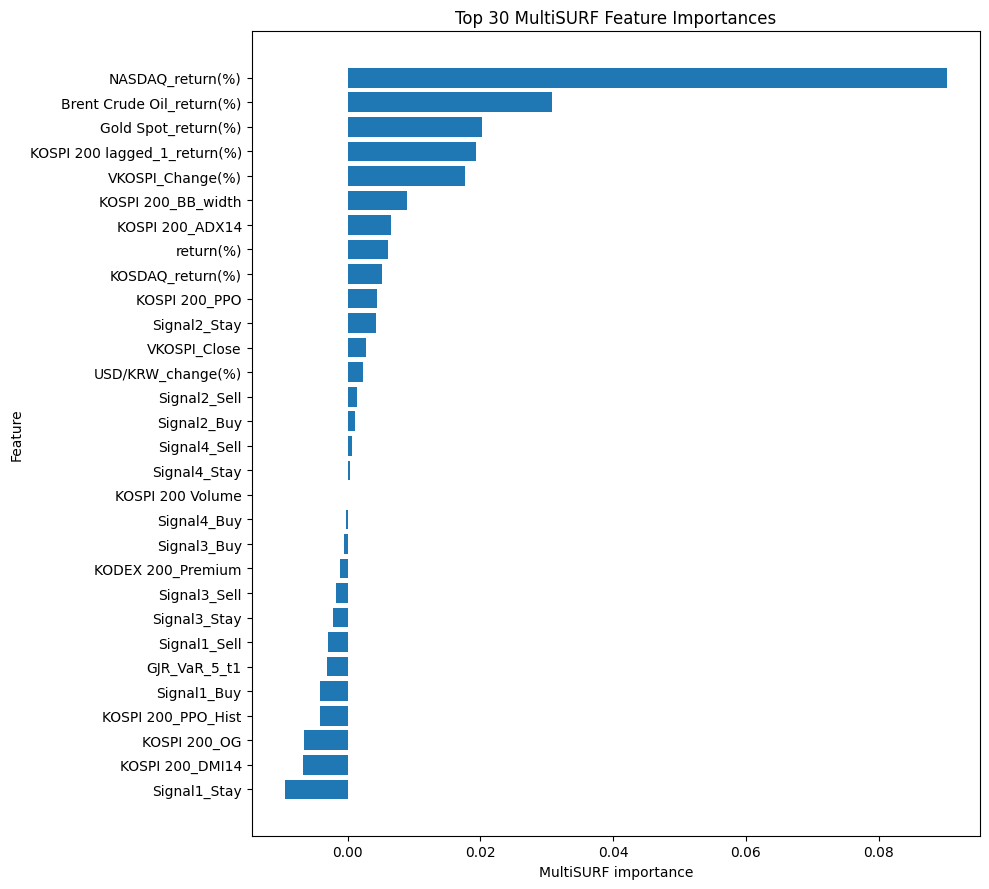

In [13]:
# =========================
# 10. 중요도 시각화
# =========================
plot_df = importance_df.head(30).sort_values('importance')

plt.figure(figsize=(10, max(6, len(plot_df) * 0.3)))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.xlabel("MultiSURF importance")
plt.ylabel("Feature")
plt.title("Top 30 MultiSURF Feature Importances")
plt.tight_layout()
plt.show()

In [14]:
# =========================
# 11. 선택 변수만 남기기
# =========================
X_train_ms = X_train_scaled[final_features].copy()
X_valid_ms = X_valid_scaled[final_features].copy()
X_test_ms = X_test_scaled[final_features].copy()

data_train_ms = pd.concat(
    [X_train_ms.reset_index(drop=True), y_train.reset_index(drop=True).rename('Risk_Label')],
    axis=1
)

data_valid_ms = pd.concat(
    [X_valid_ms.reset_index(drop=True), y_valid.reset_index(drop=True).rename('Risk_Label')],
    axis=1
)

data_test_ms = pd.concat(
    [X_test_ms.reset_index(drop=True), y_test.reset_index(drop=True).rename('Risk_Label')],
    axis=1
)

print(data_train_ms.columns.tolist())
print(data_valid_ms.columns.tolist())
print(data_test_ms.columns.tolist())

['NASDAQ_return(%)', 'Brent Crude Oil_return(%)', 'Gold Spot_return(%)', 'KOSPI 200 lagged_1_return(%)', 'VKOSPI_Change(%)', 'KOSPI 200_BB_width', 'KOSPI 200_ADX14', 'return(%)', 'KOSDAQ_return(%)', 'KOSPI 200_PPO', 'Risk_Label']
['NASDAQ_return(%)', 'Brent Crude Oil_return(%)', 'Gold Spot_return(%)', 'KOSPI 200 lagged_1_return(%)', 'VKOSPI_Change(%)', 'KOSPI 200_BB_width', 'KOSPI 200_ADX14', 'return(%)', 'KOSDAQ_return(%)', 'KOSPI 200_PPO', 'Risk_Label']
['NASDAQ_return(%)', 'Brent Crude Oil_return(%)', 'Gold Spot_return(%)', 'KOSPI 200 lagged_1_return(%)', 'VKOSPI_Change(%)', 'KOSPI 200_BB_width', 'KOSPI 200_ADX14', 'return(%)', 'KOSDAQ_return(%)', 'KOSPI 200_PPO', 'Risk_Label']
